In [5]:
import sys
import os

sys.path.append(os.path.abspath(".."))
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Imbalance Handling (for Task 2)
from imblearn.over_sampling import SMOTE

# Utility
from pathlib import Path
import warnings

# Import custom functions
from src.data_preprocessing import (
    load_data,
    clean_fraud_data,
    clean_creditcard_data
)

from src.feature_engineering import (
    create_time_features,
    create_user_transaction_count,
    create_device_transaction_count,
    map_country
)

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [8]:
fraud_df = load_data("../data/processed/fraud_clean.csv")
ip_df = load_data("../data/raw/IpAddress_to_Country.csv")

fraud_df.head()

Loaded: ../data/processed/fraud_clean.csv
Loaded: ../data/raw/IpAddress_to_Country.csv


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [9]:
print(fraud_df.shape)
print(fraud_df.info())

(151112, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB
None


In [10]:
fraud_df = clean_fraud_data(fraud_df)

In [11]:
fraud_df = create_time_features(fraud_df)

fraud_df[[
    "signup_time",
    "purchase_time",
    "time_since_signup",
    "hour_of_day",
    "day_of_week"
]].head()

,signup_time,purchase_time,time_since_signup,hour_of_day,day_of_week
0,2015-02-24 22:55:49,2015-04-18 02:47:11,4506682.0,2,5
1,2015-06-07 20:39:50,2015-06-08 01:38:54,17944.0,1,0
2,2015-01-01 18:52:44,2015-01-01 18:52:45,1.0,18,3
3,2015-04-28 21:13:25,2015-05-04 13:54:50,492085.0,13,0
4,2015-07-21 07:09:52,2015-09-09 18:40:53,4361461.0,18,2


In [12]:
fraud_df = create_user_transaction_count(fraud_df)

fraud_df[["user_id", "user_transaction_count"]].head()

,user_id,user_transaction_count
0,22058,1
1,333320,1
2,1359,1
3,150084,1
4,221365,1


In [13]:
fraud_df = create_device_transaction_count(fraud_df)

fraud_df[["device_id", "device_transaction_count"]].head()

,device_id,device_transaction_count
0,QVPSPJUOCKZAR,1
1,EOGFQPIZPYXFZ,1
2,YSSKYOSJHPPLJ,12
3,ATGTXKYKUDUQN,1
4,NAUITBZFJKHWW,1


In [14]:
fraud_df["ip_address"] = fraud_df["ip_address"].astype(np.int64)

ip_df["lower_bound_ip_address"] = ip_df["lower_bound_ip_address"].astype(np.int64)
ip_df["upper_bound_ip_address"] = ip_df["upper_bound_ip_address"].astype(np.int64)

fraud_geo = map_country(fraud_df, ip_df)

fraud_geo[["ip_address", "country"]].head()

,ip_address,country
634,16778864,Australia
635,16842045,Thailand
636,16843656,China
637,16938732,China
638,16971984,Thailand


In [15]:
country_fraud = (
    fraud_geo.groupby("country")["class"]
    .mean()
    .sort_values(ascending=False)
)

country_fraud.head(10)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Name: class, dtype: float64

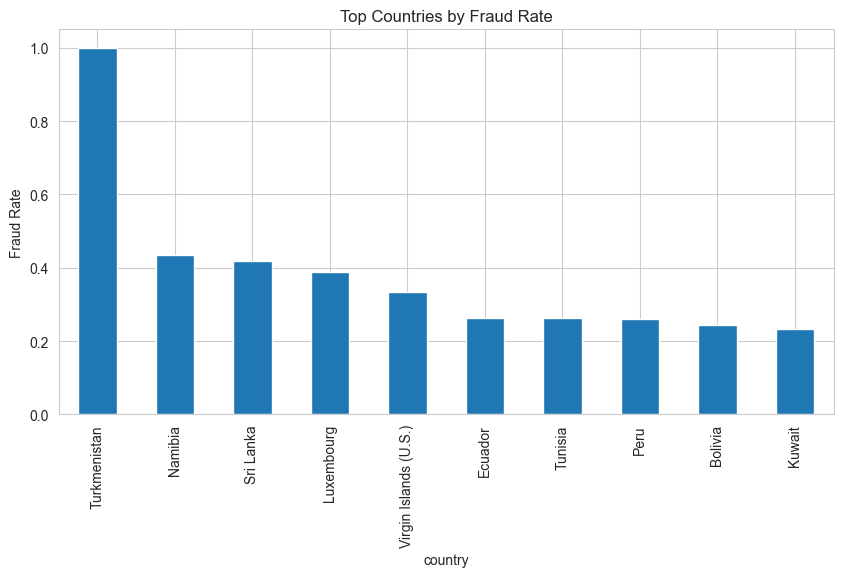

In [16]:
plt.figure(figsize=(10,5))

country_fraud.head(10).plot(kind="bar")

plt.title("Top Countries by Fraud Rate")
plt.ylabel("Fraud Rate")

plt.show()

In [17]:
fraud_geo = pd.get_dummies(
    fraud_geo,
    columns=["source", "browser", "sex", "country"],
    drop_first=True
)

In [18]:
print(fraud_geo.shape)
fraud_geo.head()

(129146, 202)


,user_id,signup_time,purchase_time,purchase_value,device_id,age,ip_address,class,time_since_signup,hour_of_day,day_of_week,user_transaction_count,device_transaction_count,lower_bound_ip_address,upper_bound_ip_address,source_Direct,source_SEO,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_M,country_Albania,country_Algeria,country_Angola,country_Antigua and Barbuda,country_Argentina,country_Armenia,country_Australia,country_Austria,country_Azerbaijan,country_Bahamas,country_Bahrain,country_Bangladesh,country_Barbados,country_Belarus,country_Belgium,country_Belize,country_Benin,country_Bermuda,country_Bhutan,country_Bolivia,country_Bonaire; Sint Eustatius; Saba,country_Bosnia and Herzegowina,country_Botswana,country_Brazil,country_British Indian Ocean Territory,country_Brunei Darussalam,country_Bulgaria,country_Burkina Faso,country_Burundi,country_Cambodia,country_Cameroon,country_Canada,country_Cape Verde,country_Cayman Islands,country_Chile,country_China,country_Colombia,country_Congo,country_Congo The Democratic Republic of The,country_Costa Rica,country_Cote D'ivoire,country_Croatia (LOCAL Name: Hrvatska),country_Cuba,country_Curacao,country_Cyprus,country_Czech Republic,country_Denmark,country_Djibouti,country_Dominica,country_Dominican Republic,country_Ecuador,country_Egypt,country_El Salvador,country_Estonia,country_Ethiopia,country_European Union,country_Faroe Islands,country_Fiji,country_Finland,country_France,country_Gabon,country_Gambia,country_Georgia,country_Germany,country_Ghana,country_Gibraltar,country_Greece,country_Guadeloupe,country_Guam,country_Guatemala,country_Haiti,country_Honduras,country_Hong Kong,country_Hungary,country_Iceland,country_India,country_Indonesia,country_Iran (ISLAMIC Republic Of),country_Iraq,country_Ireland,country_Israel,country_Italy,country_Jamaica,country_Japan,country_Jordan,country_Kazakhstan,country_Kenya,country_Korea Republic of,country_Kuwait,country_Kyrgyzstan,country_Lao People's Democratic Republic,country_Latvia,country_Lebanon,country_Lesotho,country_Libyan Arab Jamahiriya,country_Liechtenstein,country_Lithuania,country_Luxembourg,country_Macau,country_Macedonia,country_Madagascar,country_Malawi,country_Malaysia,country_Maldives,country_Malta,country_Mauritius,country_Mexico,country_Moldova Republic of,country_Monaco,country_Mongolia,country_Montenegro,country_Morocco,country_Mozambique,country_Myanmar,country_Namibia,country_Nauru,country_Nepal,country_Netherlands,country_New Caledonia,country_New Zealand,country_Nicaragua,country_Niger,country_Nigeria,country_Norway,country_Oman,country_Pakistan,country_Palestinian Territory Occupied,country_Panama,country_Papua New Guinea,country_Paraguay,country_Peru,country_Philippines,country_Poland,country_Portugal,country_Puerto Rico,country_Qatar,country_Reunion,country_Romania,country_Russian Federation,country_Rwanda,country_Saint Kitts and Nevis,country_Saint Martin,country_San Marino,country_Saudi Arabia,country_Senegal,country_Serbia,country_Seychelles,country_Singapore,country_Slovakia (SLOVAK Republic),country_Slovenia,country_South Africa,country_South Sudan,country_Spain,country_Sri Lanka,country_Sudan,country_Sweden,country_Switzerland,country_Syrian Arab Republic,country_Taiwan; Republic of China (ROC),country_Tajikistan,country_Tanzania United Republic of,country_Thailand,country_Trinidad and Tobago,country_Tunisia,country_Turkey,country_Turkmenistan,country_Uganda,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
634,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,30,16778864,0,3632215.0,3,6,1,1,16778240.0,16779263.0,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fa

In [19]:
fraud_geo.to_csv(
    "../data/processed/fraud_feature_engineered.csv",
    index=False
)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Ireland                  0.229167
New Zealand              0.223022
Uzbekistan               0.200000
Lithuania                0.189474
Saudi Arabia             0.189394
Malta                    0.181818
Afghanistan              0.166667
Cote D'ivoire            0.166667
Denmark                  0.159184
Chile                    0.153477
Name: class, dtype: float64

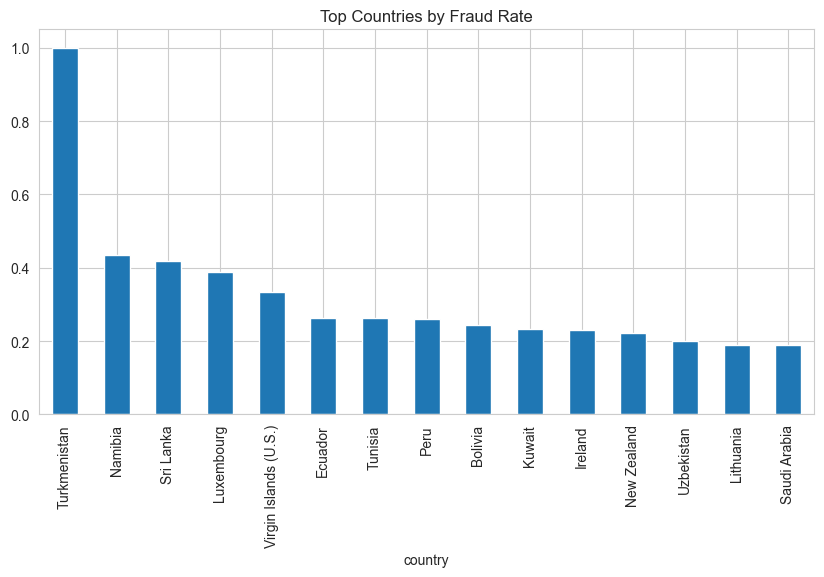

In [20]:
print("Final Features Created:")
print("- time_since_signup")
print("- hour_of_day")
print("- day_of_week")
print("- user_transaction_count")
print("- device_transaction_count")
print("- country (encoded)")
print("- source (encoded)")
print("- browser (encoded)")
print("- sex (encoded)")

Final Features Created:
- time_since_signup
- hour_of_day
- day_of_week
- user_transaction_count
- device_transaction_count
- country (encoded)
- source (encoded)
- browser (encoded)
- sex (encoded)


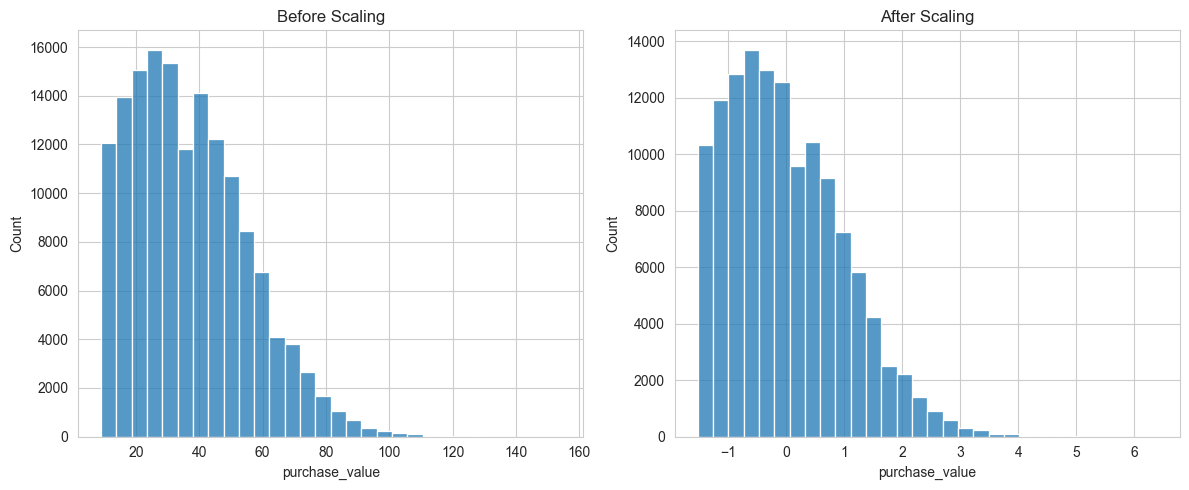

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(fraud_df["purchase_value"], bins=30, ax=axes[0])
axes[0].set_title("Before Scaling")

sns.histplot(fraud_geo["purchase_value"], bins=30, ax=axes[1])
axes[1].set_title("After Scaling")

plt.tight_layout()
plt.show()